# Aashma Dangol
# 2408023

1️⃣ Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Update Dataset Paths

In [ ]:
train_dir = "/content/drive/MyDrive/FruitinAmazon/train"
test_dir = "/content/drive/MyDrive/FruitinAmazon/test"

Data Visualization

Classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


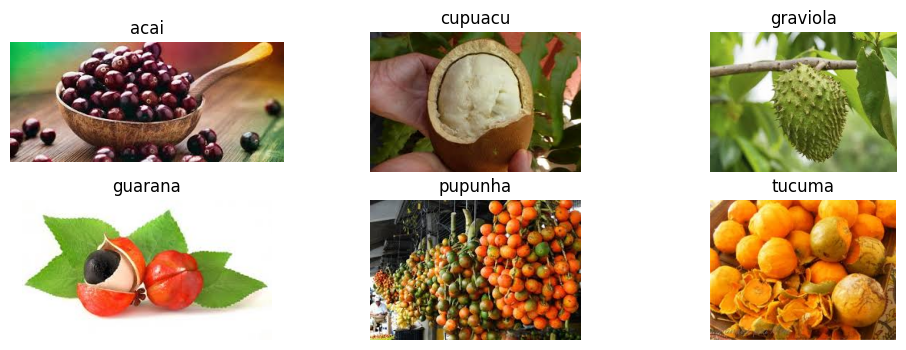

In [ ]:
import os
from PIL import Image
import matplotlib.pyplot as plt

class_names = sorted(os.listdir(train_dir))
print("Classes:", class_names)

plt.figure(figsize=(12, 4))
for i, class_name in enumerate(class_names):
    class_path = os.path.join(train_dir, class_name)
    img_name = os.listdir(class_path)[0]
    img_path = os.path.join(class_path, img_name)
    img = Image.open(img_path)
    plt.subplot(2, len(class_names)//2, i+1)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis("off")
plt.show()

2.Check for Corrupted Images

In [ ]:
removed_images = []
for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    for img_file in os.listdir(class_path):
        img_path = os.path.join(class_path, img_file)
        try:
            Image.open(img_path).verify()
        except (IOError, SyntaxError):
            os.remove(img_path)
            removed_images.append(img_path)
            print(f"Removed corrupted image: {img_path}")

if not removed_images:
    print("No corrupted images found.")

No corrupted images found.


3.Load & Preprocess Image Data

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers

img_height = 128
img_width = 128
batch_size = 16
validation_split = 0.2

rescale = layers.Rescaling(1./255)

# Both subsets must use the same directory (case-sensitive)
dataset_dir = "/content/drive/MyDrive/FruitinAmazon/train"  # mounted path

# Training dataset
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    validation_split=validation_split,
    subset='training',
    seed=123
).map(lambda x, y: (rescale(x), y))

# Validation dataset
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    validation_split=validation_split,
    subset='validation',
    seed=123
).map(lambda x, y: (rescale(x), y))

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.


4.Build CNN Model

In [ ]:
from tensorflow.keras import models
from tensorflow.keras import layers

num_classes = len(class_names)

model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(img_height, img_width, 3)),
    layers.MaxPooling2D((2,2), strides=2),
    layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2), strides=2),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,116,454 (8.07 MB)

 Trainable params: 2,116,454 (8.07 MB)

 Non-trainable params: 0 (0.00 B)

5.Compile & Train Model

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

checkpoint = ModelCheckpoint("best_model.h5", save_best_only=True, monitor="val_accuracy", mode="max")
early_stop = EarlyStopping(monitor="val_accuracy", patience=15, restore_best_weights=True)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=250,
    callbacks=[checkpoint, early_stop]
)

Epoch 1/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step - accuracy: 0.1656 - loss: 2.0923

5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 400ms/step - accuracy: 0.1667 - loss: 2.2134 - val_accuracy: 0.1667 - val_loss: 2.0635
Epoch 2/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 442ms/step - accuracy: 0.2271 - loss: 1.7541

5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 559ms/step - accuracy: 0.3333 - loss: 1.6960 - val_accuracy: 0.2222 - val_loss: 1.7720
Epoch 3/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 301ms/step - accuracy: 0.3611 - loss: 1.4720 - val_accuracy: 0.1111 - val_loss: 1.9267
Epoch 4/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 248ms/step - accuracy: 0.4378 - loss: 1.3473

5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 344ms/step - accuracy: 0.4861 - loss: 1.3080 - val_accuracy: 0.2778 - val_loss: 1.6414
Epoch 5/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 367ms/step - accuracy: 0.6944 - loss: 1.0910 - val_accuracy: 0.2778 - val_loss: 1.8363
Epoch 6/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 300ms/step - accuracy: 0.7222 - loss: 0.9464 - val_accuracy: 0.1667 - val_loss: 1.8518
Epoch 7/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 302ms/step - accuracy: 0.9017 - loss: 0.5926

5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 417ms/step - accuracy: 0.8472 - loss: 0.6655 - val_accuracy: 0.3889 - val_loss: 1.5612
Epoch 8/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 612ms/step - accuracy: 0.8889 - loss: 0.4399 - val_accuracy: 0.3333 - val_loss: 2.1077
Epoch 9/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 361ms/step - accuracy: 0.8889 - loss: 0.3757 - val_accuracy: 0.2778 - val_loss: 2.1561
Epoch 10/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 251ms/step - accuracy: 0.9517 - loss: 0.2541

5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 323ms/step - accuracy: 0.9306 - loss: 0.2646 - val_accuracy: 0.4444 - val_loss: 2.1677
Epoch 11/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 301ms/step - accuracy: 0.9306 - loss: 0.1788 - val_accuracy: 0.3333 - val_loss: 2.0979
Epoch 12/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 311ms/step - accuracy: 1.0000 - loss: 0.0613 - val_accuracy: 0.3333 - val_loss: 2.4890
Epoch 13/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 343ms/step - accuracy: 0.9861 - loss: 0.0457 - val_accuracy: 0.3333 - val_loss: 2.0700
Epoch 14/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 333ms/step - accuracy: 1.0000 - loss: 0.0246 - val_accuracy: 0.3333 - val_loss: 2.1624
Epoch 15/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 731ms/step - accuracy: 1.0000 - loss: 0.0252 - val_accuracy: 0.3889 - val_loss: 2.0406
Epoch 16/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 422ms/step - accuracy: 1.0000 - loss: 0.0081 - val_accuracy: 0.3333 - val_loss: 2.6677
Epoch 17/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 331ms/step - accuracy: 1.0000 - loss: 0.0092 - val_accuracy: 0.3889 - val_lo

6.Evaluate on Test Set

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers

img_height = 128
img_width = 128
batch_size = 16

rescale = layers.Rescaling(1./255)

# Path to test dataset (case-sensitive)
test_dir = "/content/drive/MyDrive/FruitinAmazon/test"

# Load test dataset
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=False
).map(lambda x, y: (rescale(x), y))

# Evaluate the model (make sure 'model' is trained and defined!)
test_loss, test_acc = model.evaluate(test_ds)
print(f"Test Accuracy: {test_acc:.4f}")

# Save the trained model
model.save("/content/drive/MyDrive/FruitinAmazon/final_model.h5")

Found 30 files belonging to 6 classes.
2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 2s/step - accuracy: 0.7000 - loss: 1.2916


Test Accuracy: 0.7000


7.Predictions & Classification Report

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

        acai       0.62      1.00      0.77         5
     cupuacu       0.80      0.80      0.80         5
    graviola       1.00      1.00      1.00         5
     guarana       0.50      1.00      0.67         5
     pupunha       0.00      0.00      0.00         5
      tucuma       1.00      0.40      0.57         5

    accuracy                           0.70        30
   macro avg       0.65      0.70      0.63        30
weighted avg       0.65      0.70      0.63        30



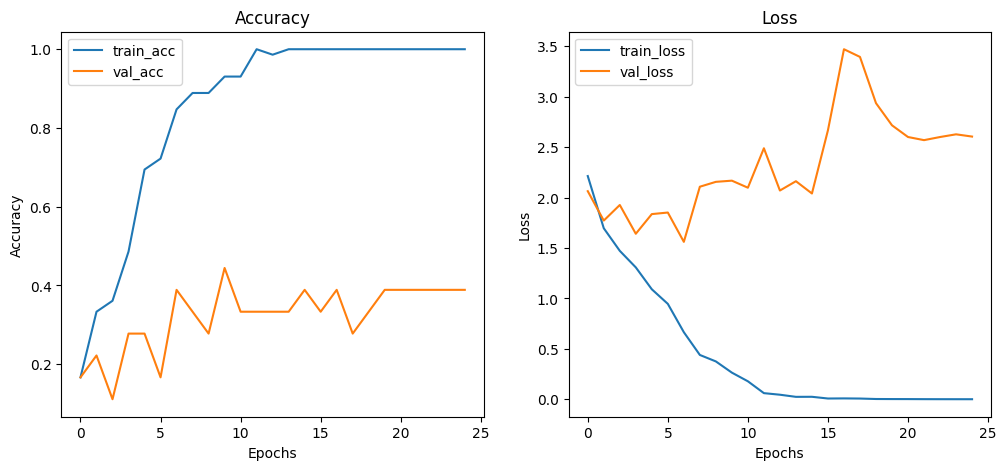

In [ ]:
import numpy as np
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

# True labels
y_true = np.concatenate([y for x, y in test_ds], axis=0)

# Predictions
y_pred_probs = model.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

# Classification report
report = classification_report(y_true, y_pred, target_names=class_names)
print(report)

# Plot training history
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.title("Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title("Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()